# **Linear Regression: Analytical Approach**

In linear regression, we want to find the line that best fits a given set of data points.

We assume the relationship between the input $x$ and output $y$ is:

$$
\hat{y} = mx + b
$$

where:

- $m$ is the slope of the line
- $b$ is the y-intercept
- $\hat{y}$ is the predicted value

In this notebook, we will find $m$ and $b$ using an **analytical approach**.

We will not use gradient descent here. Instead, we will minimize the total squared error mathematically by taking partial derivatives and solving them.

In [17]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## 1. Dataset

Let's consider the following three data points:

$$
(1,2),\quad (2,5),\quad (3,3)
$$

Our goal is to find the line:

$$
\hat{y} = mx + b
$$

that best fits these points.

In [9]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

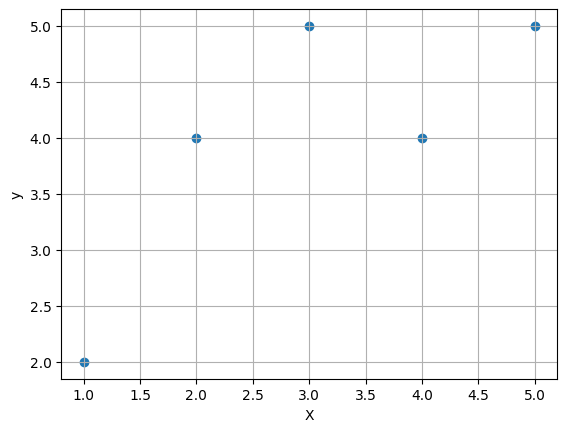

In [12]:
plt.grid()
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## 2. Linear Model

We assume that our model is:

$$
\hat{y} = mx + b
$$

For each input $x$, the model produces a prediction $\hat{y}$.

For example, for the first point $(1,2)$:

$$
\hat{y} = m(1) + b = m+b
$$

## 3. Squared Error

For each data point, we calculate the difference between the predicted value and the actual value.

The squared error is:

$$
E = (\hat{y} - y)^2
$$

We square the error so that positive and negative errors do not cancel each other out.

## 4. Error for Each Data Point

For the point $(1,2)$:

$$
E_1 = (m+b-2)^2
$$

For the point $(2,5)$:

$$
E_2 = (2m+b-5)^2
$$

For the point $(3,3)$:

$$
E_3 = (3m+b-3)^2
$$

## 5. Total Cost

We combine the squared errors to obtain the total cost:

$$
J(m,b) =
(m+b-2)^2
+
(2m+b-5)^2
+
(3m+b-3)^2
$$

Our goal is to find the values of $m$ and $b$ that minimize this function:

$$
\min_{m,b} J(m,b)
$$

In [19]:
m, b = sp.symbols('m b')

J = (
    (m + b - 2)**2 +
    (2*m + b - 5)**2 +
    (3*m + b - 3)**2
)

J

(b + m - 2)**2 + (b + 2*m - 5)**2 + (b + 3*m - 3)**2

## 6. Partial Derivatives

The cost function depends on two variables, $m$ and $b$.

To find the minimum, we take the partial derivative with respect to each variable:

$$
\frac{\partial J}{\partial m}
$$

and

$$
\frac{\partial J}{\partial b}
$$

At the minimum, both partial derivatives are zero:

$$
\frac{\partial J}{\partial m}=0
$$

$$
\frac{\partial J}{\partial b}=0
$$

In [20]:
dJ_dm = sp.diff(J, m)
dJ_db = sp.diff(J, b)

dJ_dm, dJ_db

(12*b + 28*m - 42, 6*b + 12*m - 20)

## 7. Solve the Equations

We now solve the two equations:

$$
\frac{\partial J}{\partial m}=0
$$

$$
\frac{\partial J}{\partial b}=0
$$

This gives us the values of $m$ and $b$ that minimize the total squared error.

In [15]:
solution = sp.solve(
    [dJ_dm, dJ_db],
    [m, b]
)

solution

{b: 7/3, m: 1/2}

## 8. Regression Line

The analytical solution gives us:

$$
m = \frac{1}{2}
$$

and

$$
b = \frac{7}{3}
$$

Substituting these into our model:

$$
\hat{y} = mx+b
$$

we obtain:

$$
\boxed{\hat{y} = \frac{1}{2}x+\frac{7}{3}}
$$

This is the line that minimizes the total squared error for our dataset.

In [21]:
m_value = solution[m]
b_value = solution[b]

y_pred = float(m_value) * X + float(b_value)

print("m =", m_value)
print("b =", b_value)
print("Predictions =", y_pred)

m = 1/2
b = 7/3
Predictions = [2.83333333 3.33333333 3.83333333 4.33333333 4.83333333]


## 9. Visualizing the Regression Line

Let's visualize the original data points and the line obtained from our analytical solution.

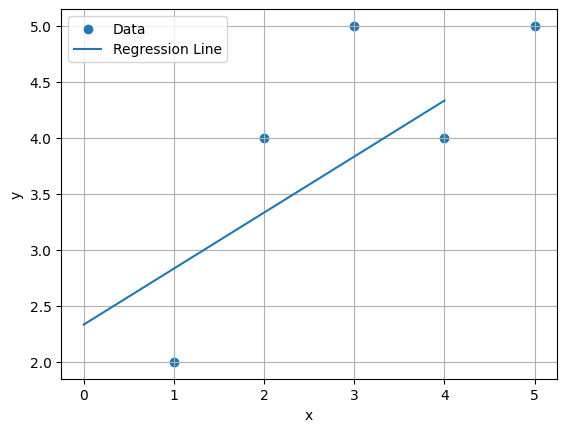

In [23]:
plt.scatter(X, y, label="Data")

x_line = np.linspace(0, 4, 100)
y_line = float(m_value) * x_line + float(b_value)

plt.plot(x_line, y_line, label="Regression Line")
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Conclusion

We found the optimal linear model without using an iterative optimization algorithm.

The process was:

$$
\text{Data}
\rightarrow
\text{Linear Model}
\rightarrow
\text{Squared Errors}
\rightarrow
\text{Total Cost}
\rightarrow
\text{Partial Derivatives}
\rightarrow
\text{Set Derivatives to Zero}
\rightarrow
\text{Solve for }m,b
$$

For this dataset, the resulting regression line is:

$$
\boxed{\hat{y} = \frac{1}{2}x+\frac{7}{3}}
$$

This is the **analytical approach** to linear regression.

In the next section, we can approach the same problem using **gradient descent**, where we will no longer solve for the optimal parameters directly.